In [1]:
# Tensorflow Keras and rest of the packages
import tensorflow as tf
import keras as keras
from tensorflow.keras import models,Model
from tensorflow.keras.layers import Dense,Input
from tensorflow.keras.optimizers import Adam,SGD,RMSprop
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import ModelCheckpoint
import scipy

In [2]:
plt.rcParams.update({
    'font.size': 14,           # Tamaño base de la fuente
    'axes.labelsize': 16,      # Tamaño de las etiquetas de los ejes (xlabel, ylabel)
    'axes.titlesize': 18,      # Tamaño del título de la gráfica
    'xtick.labelsize': 14,     # Tamaño de los números de la escala X
    'ytick.labelsize': 14,     # Tamaño de los números de la escala Y
    'legend.fontsize': 14,     # Tamaño del texto de la leyenda
    'figure.titlesize': 20     # Tamaño del título general de la figura (si usas suptitle)
})

In [3]:
def nn_model(activation,neurons_layer,n_layers):
    input=Input(shape=(neurons_layer[0],))
    x=input
    for hidden_layer_neurons in neurons_layer[1:-1]: 
        x=Dense(hidden_layer_neurons,activation=activation)(x)
    output=Dense(neurons_layer[n_layers-1])(x)
    return input,output

In [26]:
@keras.saving.register_keras_serializable()#Esto hace que se pueda guardar el modelo y cargarlo sin problemas despues
class EVE_PINN(tf.keras.Model):# Esta clase va a heredar de la clase Model de Keras, lo que nos permite usar todos los metodos de la clase Model y ademas definir nuestros propios metodos
    def set_step_dx(self,dx): #Este metodo inicializa la clase
        self.dx=dx #Lo que hace esto es que al objeto que luego instanciamos le asigna el atributo dx, que va a ser espaciado entre puntos
    def set_V(self,V):
        self.V=V
    def set_max_min(self,xmax,xmin):
        self.xmax=xmax
        self.xmin=xmin
    def train_step(self, data):#Metodo que tiene internamente la clase Model del API de Keras
        x, y_exact = data

        #Change initial conditions for the PINN
        x_max=self.xmax
        x_min=self.xmin
        x_max=tf.constant([x_max],dtype=tf.float32)
        x_min=tf.constant([x_min],dtype=tf.float32)
        xi = tf.reshape(x,(x.shape[0],1))#Reconversion del batch de entrada a un vector columna
        unit = tf.constant(1.0, dtype=tf.float32)
        unit = tf.reshape(unit,shape=xi[0].shape)
        V=tf.constant(self.V, dtype=tf.float32)
        # loss set to zero
        print(V.shape)
        # Averaged eigenvalue
        cero=tf.constant(0.0, dtype=tf.float32)
        # Spatial mesh
        dx = tf.constant(self.dx,dtype=tf.float32)

        with tf.GradientTape() as tape:
            ymax=(xmax-xmax)*(xmax+xmax)*self(x_max,training=False)
            ymin=(xmin-xmax)*(xmin+xmax)*self(x_min,training=False)
            # Calculate the second derivative dy2/dx2
            with tf.GradientTape() as tape1:
                tape1.watch(xi)
                with tf.GradientTape() as tape2:
                    tape2.watch(xi)#Watch le dice en que tensor se tiene que fijar para los calculos, aqui le decimos que mire el batch de entrada porque luego lo utilizamos para calcular la salida, esto es asi porque tape solo se fija en tensores variables y xi es constante 
                    y_NN =(xi-xmax)*(xi+xmax)*self(xi,training=False)#Cálculo de la y_NN para todos los datos, self(xi) hace el paso hacia delante del batch de entrada, y multplicamos por hard_condition para asegurar que la salida cumple las condiciones de contorno. Training=false porque esto solo sirve para calcular la funcion de perdida, es decir, estamos haciendo un predict de los datos xi de entrada
                    print(y_NN.shape)#Esto devolvera cual es el tamaño de la salida, que sera de otro vector columna, cada elemento la salida de cada dato de entrada del batch
                    tape2.watch(y_NN)#Ahora que esta calculada la salida, nos fijamos en el tensor de salida, de forma que ya podremos hacer la derivada
                dy_dx_NN = tape2.gradient(y_NN, xi)#Calcula la derivada de la salida respecto a la entrada, nos devolvera otro vector
                tape1.watch(y_NN)#De nuevo, se tiene que fijar
                tape1.watch(dy_dx_NN)#...
            d2y_dx2_NN = tf.squeeze(tape1.gradient(dy_dx_NN, xi))#Segunda derivada
            y_NN = tf.squeeze(y_NN)#Squeeze elimina las dimensiones de tamaño a 1 en lso tensores, osea si tenemos un vector que seria un tensor de shape(y,1) al hacer squeeze pasa a ser solo de shape(y,)
            tape.watch(xi)
            tape.watch(y_NN)
            tape.watch(dy_dx_NN)
            tape.watch(d2y_dx2_NN)
    
            num = tf.reduce_sum(y_NN*(-d2y_dx2_NN+V*y_NN))#Esto es el producto escalar de y con la segunda derivada de y, no se multiplica por dx porque se va a ir luego al ser un cociente num/den
            den = tf.reduce_sum(tf.square(y_NN)) # Could this be zero? #Norma al cuadrado de y
            M = num/den #Funcio de perdidad, que intentamos que cuando sea minima coincida con el autoestado fundamental
            M = tf.reshape(M,shape=xi[0].shape)#Reconvertimos en tensor de tamaño 0 porque era un esacalar, a un tensor de tamaño, que solo tiene un elemento que es el escalar.


            I = tf.math.reduce_sum(tf.square(y_NN))
            I = I*dx
            I = tf.reshape(I,shape=xi[0].shape)#Se van creando copias de I hasta que llegamos al tensor que es ahora si la morma al cuadrado multiplicada por el factor dx de discretizacion, tambien es de dimension 1con el reshape

            #Loss= ODE+ boundary/initial conditions
            lossDE = self.compiled_loss(-d2y_dx2_NN+V*y_NN, M*y_NN) #Esta loss lo que tiene interesante es que self.compiled_loss va a recibir como primer argumento el valor real bueno, y como segundo al valor predicho. Luego, cuando llamamos al metodo compile y le pasamos que tipo de metrica queremos, hara cuentas con ello
            loss = tf.squeeze(M + self.compiled_loss(I,unit))  #  Esta loss es el autovalor mas la condicion de normalizacion, esta es con la que entrenamos
            kinetic = tf.reduce_sum(y_NN * (-d2y_dx2_NN)) / tf.reduce_sum(tf.square(y_NN))
            potential = tf.reduce_sum(y_NN * (V * y_NN)) / tf.reduce_sum(tf.square(y_NN))

        gradients = tape.gradient(loss, self.trainable_weights)#Calcula la derivada de la funcion de perdida respecto a los parametros entrenables
        self.optimizer.apply_gradients(zip(gradients, self.trainable_weights))#Zip empareja cada derivada de la lista gradientes con el parametro respecto al que se ha derivad0, de forma que le pasamos este tensor al optimizador que aplicara los gradientes y actualiza los parametros
        self.compiled_metrics.update_state(y_exact, y_NN)#Por ultimo, se actualiza el estado respecto al paso anterior con la y_NN calculada en este nuevo paso con los parametros anteriores
        metrics = {m.name: m.result() for m in self.metrics}#Dado que entiendo que el metodo self.compiled_metrics.updatestate actualiza las metricas como atributo del objeto en self.metrics. {} Crea un diccionario, en el que el formato_:_ indica clave:valor asociado 
        metrics['DE']=lossDE
        metrics['loss']=loss
        metrics['I']=I
        metrics['E']=M
        metrics['ymax']=ymax
        metrics['ymin']=ymin
        metrics['Kinetic']=kinetic
        metrics['Potential']=potential
        return metrics#Este diccionario creado que devuelve el metodo traning_step es el que utiliza model.fit para calcular las metricas

In [27]:
## Custom metric
@keras.saving.register_keras_serializable()#La serializamos para que despues al cargar el modelo, no tengamos que haber definido previamente la funcion, simplemente la habra guardado ya.
def mse_odd_even_sol(y_true, y_pred):
    return tf.minimum(tf.reduce_mean(tf.square(y_pred - y_true)),tf.reduce_mean(tf.square(y_pred + y_true)))#Devuelve el minimo entre y_NN con +-y_real 

dx= 0.02404809619238477


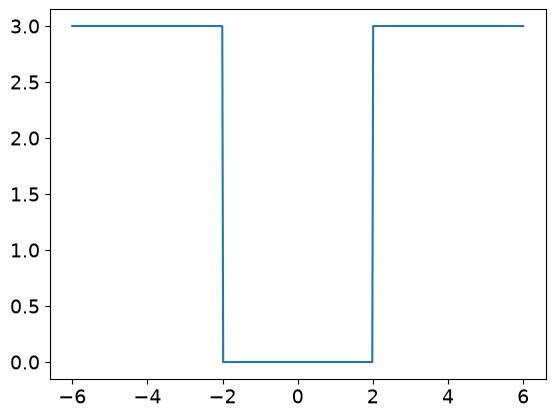

In [28]:
n_train = 500  
# Definition of the function domain
xmin=-6
xmax=6
L=4
a=L/2
V0=3
x_train,step_dx = np.linspace(xmin,xmax,n_train,retstep=True)
print("dx=",step_dx)
V=np.zeros_like(x_train)
for i in range(len(x_train)):
    if x_train[i]<=-a or x_train[i]>=a:
        V[i]=V0
    else:
        V[i]=0

# The solution y(x) for training and validation datasets
plt.plot(x_train,V)


In [29]:
# Build the model
checkpoint_callback = ModelCheckpoint(
    filepath=f"Var_E_fund_pozo_finito_L_{L}_V0_{V0}_xmax_{xmax}_n_{n_train}.weights.h5",
    monitor="mse_odd_even_sol",
    save_best_only=True,
    save_weights_only=True,
    mode="min",
    verbose=1,
)#Esto hace que cuando se lo pasemos a model.fit nos guarde solo los parametros del modelo en variacional_E_fundamental.h5 siempre que la perdida sea menor que en la anterior epoca
csv_logger =tf.keras.callbacks.CSVLogger(f'metricas_Var_E_fund_L_{L}_n_{n_train}_lr.csv', append=False)

**AUTOVALOR FUNDAMENTAL**

In [30]:
def ecuacion(E):
    rho=np.sqrt(V0-E)
    k=np.sqrt(E)
    return rho/k-np.tan(k*a)
E=scipy.optimize.root_scalar(ecuacion,bracket=[0.1,0.5],method='bisect')
print(E)


      converged: True
           flag: converged
 function_calls: 40
     iterations: 38
           root: 0.3678660235731513
         method: bisect


**AUTOESTADO FUNDAMENTAL**

0.9999998884417458


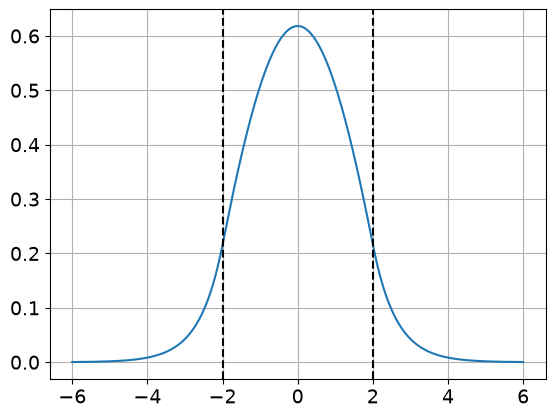

In [31]:
rho=np.sqrt(V0-E.root)
k=np.sqrt(E.root)
I1=np.exp(-L*rho)/(2*rho)
I2=a*(1+np.sin(k*L)/(k*L))
I3=np.exp(-L*rho)/(2*rho)
fact=np.exp(-rho*a)/(np.cos(k*a))
C=1/np.sqrt(I1+np.square(fact)*I2+I3)
fi=np.zeros(n_train)
for i,x in enumerate(x_train):
    if x<=-a:
        fi[i]=C*np.exp(rho*x)
    elif x>=a:
        fi[i]=C*np.exp(-rho*x)
    elif (x>-a or x<-a):
        fi[i]=C*fact*np.cos(k*x)
print(step_dx*sum(fi**2))
plt.plot(x_train,fi)
plt.axvline(-L / 2, linestyle="--", color="k")
plt.axvline(L / 2, linestyle="--", color="k")
plt.grid(True)

In [32]:
xi = tf.reshape(
    tf.constant(x_train, dtype=tf.float32),
    (-1, 1)
)

rho_tf = tf.constant(rho, dtype=tf.float32)
k_tf = tf.constant(k, dtype=tf.float32)
C_tf = tf.constant(C, dtype=tf.float32)
fact_tf = tf.constant(fact, dtype=tf.float32)
a_tf = tf.constant(a, dtype=tf.float32)

with tf.GradientTape() as tape2:
    tape2.watch(xi)

    with tf.GradientTape() as tape1:
        tape1.watch(xi)

        fi_tf = tf.where(
            xi <= -a_tf,
            C_tf * tf.exp(rho_tf * xi),
            tf.where(
                xi >= a_tf,
                C_tf * tf.exp(-rho_tf * xi),
                C_tf * fact_tf * tf.cos(k_tf * xi)
            )
        )

    dy_dx = tape1.gradient(fi_tf, xi)

d2fi_dx2 = tape2.gradient(dy_dx, xi)

fi_tf = tf.squeeze(fi_tf)
d2fi_dx2 = tf.squeeze(d2fi_dx2)

V_tf = tf.constant(V, dtype=tf.float32)

num = tf.reduce_sum(
    fi_tf * (-d2fi_dx2 + V_tf * fi_tf)
)
den = tf.reduce_sum(tf.square(fi_tf))

M = num / den
print(M.numpy())

0.367866


In [33]:
# Input and output neurons (from the data)
neurons_layer=[1, 50, 50, 50, 1]
n_layers=5


# Define the model
activation = 'tanh'
input,output = nn_model(activation,neurons_layer,n_layers)

model = EVE_PINN(input,output)
model.set_max_min(xmax,xmin)
model.set_step_dx(step_dx)
model.set_V(V)
#model.load_weights('C:\TFG\PINNS\PINNS\Pozo_infinito\Estado_fundamental_copia-1.keras')
#Define the metrics, optimizer and loss
metrics = [mse_odd_even_sol] #tf.keras.metrics.MeanSquaredError()
lr=0.001
optimizer = Adam(learning_rate=lr)

model.compile(loss='mse',
          optimizer=optimizer,
          metrics=metrics,
          run_eagerly=False)

model.summary()

Model: "eve_pinn_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 50)             │           100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,251 (20.51 KB)

 Trainable params: 5,251 (20.51 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
epochs = 6000 # 5000        
history = model.fit(x_train,fi, batch_size=n_train, epochs=epochs,
                  callbacks=[checkpoint_callback,csv_logger],shuffle=False)#Evidentemente sin validacion, tamaño del batch=n_train, cada batch es una epoca 


Epoch 1/6000


(500,)
(500, 1)
(500,)
(500, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - DE: 0.8908 - E: 3.3658 - I: 24.0646 - Kinetic: 0.4264 - Potential: 2.9394 - mse_odd_even_sol: 2.0845 - loss: 535.3422 - ymax: 0.0000e+00 - ymin: 0.0000e+00
Epoch 1: mse_odd_even_sol improved from None to 2.08454, saving model to Var_E_fund_pozo_finito_L_4_V0_3_xmax_6_n_500.weights.h5

Epoch 1: finished saving model to Var_E_fund_pozo_finito_L_4_V0_3_xmax_6_n_500.weights.h5
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - DE: 0.8908 - E: 3.3658 - I: 24.0646 - Kinetic: 0.4264 - Potential: 2.9394 - mse_odd_even_sol: 2.0845 - loss: 535.3422 - ymax: 0.0000e+00 - ymin: 0.0000e+00
Epoch 2/6000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - DE: 17.4862 - E: 2.1568 - I: 136.0754 - Kinetic: 0.3465 - Potential: 1.8103 - mse_odd_even_sol: 11.3766 - loss: 18247.5098 - ymax: 0.0000e+00 - ymin: 0.0000e+00
Epoch 2: mse_odd_even_sol did not improve from 2.08454
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - DE: 17.4862 - E: 2.1568 - I: 136.0754 - Kinetic: 0.

In [ ]:
name=f'Var_E_fund_pozo_finito_L_{L}_V0_{V0}_xmax_{xmax}_n_{n_train}.keras'
model.save(name)

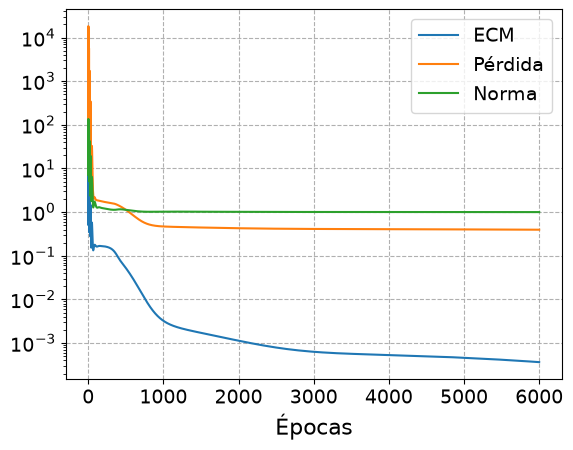

In [36]:
plt.plot(history.history['mse_odd_even_sol'],label='ECM')
plt.plot(history.history['loss'],label='Pérdida')
plt.plot(history.history['I'],label= 'Norma')
#plt.title('Método variacional pozo infinito')
plt.xlabel('Épocas')
plt.yscale("log")
plt.grid(True, linestyle="--")
plt.legend()
Imagen_metricas=f'Métricas_Var_E_fund_pozo_finito_L_{L}_n_{n_train}'
plt.savefig(Imagen_metricas, dpi=300, bbox_inches='tight')

In [37]:
neurons_layer=[1, 50, 50, 50, 1]
n_layers=5

# Define the model
activation = 'tanh'
input,output = nn_model(activation,neurons_layer,n_layers)

cloned_model = EVE_PINN(input,output)
cloned_model.set_max_min(xmax,xmin)
cloned_model.set_step_dx(step_dx)
cloned_model.set_V(V)

#Define the metrics, optimizer and loss
#metrics = [mse_odd_even_sol] #tf.keras.metrics.MeanSquaredError()
lr=0.001
optimizer = Adam(learning_rate=lr)

cloned_model.compile(loss='mse',
          optimizer=optimizer,
          run_eagerly=False)
cloned_model.load_weights(f"Var_E_fund_pozo_finito_L_{L}_V0_{V0}_xmax_{xmax}_n_{n_train}.weights.h5")

c:\Users\ruben\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\saving\saving_lib.py:843: UserWarning: Skipping variable loading for optimizer 'adam_5', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [38]:
y_best=cloned_model.predict(x_train)
y_best=np.reshape(y_best,x_train.shape)
y_NN=model.predict(x_train)
y_NN=np.reshape(y_NN,n_train)
factor=(xmax-x_train)*(xmax+x_train)
y_best=factor*y_best
y_NN=factor*y_NN

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


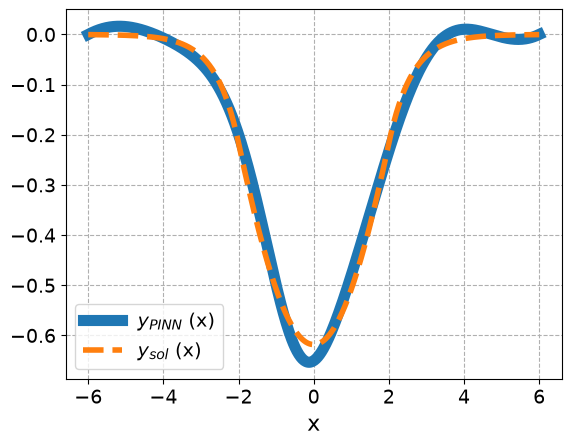

In [ ]:
#plt.plot(x_train,y_NN,lw=8,label=r'$y_{pred}$ (x)')
plt.plot(x_train,y_best,lw=8,label=r'$y_{PINN}$ (x)')
plt.plot(x_train,-fi, lw=4, linestyle='--',label=r'$y_{sol}$ (x)')
plt.xlabel('x')
plt.grid(True, linestyle="--")
plt.legend()
Imagen_y_NN=f'Res_E_fund_pozo_infinito_L_{L}_n_{n_train}'
plt.savefig(Imagen_y_NN, dpi=300, bbox_inches='tight')